# Лабораторная работа №5: Анализ последовательностей

## Цель работы
Освоить методы поиска последовательных шаблонов (AprioriAll, PrefixSpan), реализовать базовые алгоритмы, применить их к реальным данным и сравнить эффективность.

## 1. Реализация AprioriAll

Реализовать алгоритм AprioriAll с нуля на Python.

Функционал:
- Загрузка данных из CSV (поля: client_id, date, items).
- Преобразование в последовательности клиентов (сортировка по дате, группировка товаров внутри транзакции).
- Генерация кандидатов и подсчёт поддержки по клиентам.
- Поиск всех частых последовательностей.

### Вспомогательные функции и классический Apriori

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import time
import networkx as nx
import textwrap
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict
from prefixspan import PrefixSpan

def apriori(transactions, min_support): # классический Apriori для поиска частых наборов (без учёта последовательности).
    n_trans = len(transactions)
    min_cnt = max(1, int(min_support * n_trans))
    single_counts = Counter()
    for basket in transactions:
        for item in basket:
            single_counts[item] += 1
    frequent = {}
    L1 = []
    for item, cnt in single_counts.items():
        if cnt >= min_cnt:
            key = (item,)
            frequent[key] = cnt / n_trans
            L1.append(key)
    baskets_frozen = [frozenset(b) for b in transactions]
    k = 2
    prev = L1
    while prev:
        candidates = _gen_candidates(prev, k)
        if not candidates:
            break
        counter = Counter()
        for b in baskets_frozen:
            for cand in candidates:
                if cand.issubset(b):
                    counter[cand] += 1
        curr = []
        for cand, cnt in counter.items():
            if cnt >= min_cnt:
                key = tuple(sorted(cand))
                frequent[key] = cnt / n_trans
                curr.append(key)
        prev = curr
        k += 1
    return frequent

def _gen_candidates(prev, k): # генерация кандидатов
    result = []
    n = len(prev)
    for i in range(n):
        a = set(prev[i])
        for j in range(i+1, n):
            b = set(prev[j])
            if sorted(a)[:k-2] == sorted(b)[:k-2]:
                cand = a | b
                if len(cand) == k:
                    ok = True
                    for sub in itertools.combinations(cand, k-1):
                        if tuple(sorted(sub)) not in prev:
                            ok = False
                            break
                    if ok:
                        result.append(frozenset(cand))
    return result

def extract_rules(freq_itemsets, min_conf=0.5, min_lift=1.0, max_left_len=4, max_right_len=2): # извлечение ассоциативных правил из частых наборов
    rules = []
    for itemset, supp_all in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        items = set(itemset)
        for left_size in range(1, min(len(items), max_left_len+1)):
            if left_size >= len(items):
                continue
            if max_right_len and len(items)-left_size > max_right_len:
                continue
            for left in itertools.combinations(itemset, left_size):
                left = tuple(sorted(left))
                right = tuple(sorted(items - set(left)))
                supp_left = freq_itemsets.get(left, 0.0)
                if supp_left == 0.0:
                    continue
                confidence = supp_all / supp_left
                if confidence < min_conf:
                    continue
                supp_right = freq_itemsets.get(right, 0.0)
                lift = confidence / supp_right if supp_right > 0 else float('inf')
                if lift < min_lift:
                    continue
                rules.append((left, right, supp_all, confidence, lift))
    return rules

def is_subsequence(subseq, fullseq): # проверка, является ли subseq подпоследовательностью fullseq (с учётом порядка)
    it = iter(fullseq)
    for itemset in subseq:
        found = False
        for cand in it:
            if itemset.issubset(cand):
                found = True
                break
        if not found:
            return False
    return True

def seq_to_str(seq, max_items=2): # преобразует последовательность множеств в строку для отображения
    items = []
    for it in seq:
        it_list = list(it)
        if len(it_list) > max_items:
            items.append("(" + ", ".join(it_list[:max_items]) + "...)")
        else:
            items.append("(" + ", ".join(it_list) + ")")
    return " → ".join(items)

def wrap_label(text, width=15): # функция для переноса текста (разбивает на строки не длиннее 15 символов)
    return "\n".join(textwrap.wrap(text, width))

### Реализация AprioriAll

In [2]:
def apriori_all(sequences: List[List[Set]], min_support: float) -> Dict[Tuple, float]: # алгоритм AprioriAll для поиска частых последовательностей
    n_clients = len(sequences)
    min_count = max(1, int(min_support * n_clients))
    print(f"Клиентов: {n_clients}, min_sup={min_support} -> min_count={min_count}")

    # частые 1-элементные последовательности
    item_counts = Counter()
    for seq in sequences:
        unique_items = set()
        for itemset in seq:
            unique_items.update(itemset)
        for item in unique_items:
            item_counts[item] += 1
    freq1 = {(frozenset([item]),): cnt/n_clients for item, cnt in item_counts.items() if cnt >= min_count}
    all_freq = dict(freq1)
    prev_freq = list(freq1.keys())

    k = 2
    while prev_freq:
        candidates = set()
        # слияние двух последовательностей длины k-1
        for i in range(len(prev_freq)):
            for j in range(i+1, len(prev_freq)):
                seq_i = prev_freq[i]
                seq_j = prev_freq[j]
                if seq_i[:-1] == seq_j[:-1]:
                    candidates.add(seq_i + (seq_j[-1],))
        # расширение последовательности новым itemset
        for seq in prev_freq:
            for itemset, _ in freq1.items():
                candidates.add(seq + itemset)
        # отсеиваем кандидатов, у которых есть неподдерживаемая подпоследовательность
        valid = []
        for cand in candidates:
            ok = True
            for i in range(len(cand)):
                sub = cand[:i] + cand[i+1:]
                if sub not in all_freq:
                    ok = False
                    break
            if ok:
                valid.append(cand)
        if not valid:
            break
        # подсчёт поддержки
        counts = defaultdict(int)
        for seq in sequences:
            for cand in valid:
                if is_subsequence(cand, seq):
                    counts[cand] += 1
        curr_freq = []
        for cand, cnt in counts.items():
            if cnt >= min_count:
                sup = cnt / n_clients
                all_freq[cand] = sup
                curr_freq.append(cand)
        prev_freq = curr_freq
        k += 1
        print(f"  Длина {k-1}: найдено {len(curr_freq)} частых последовательностей")
    return all_freq

### Проверка на синтетическом примере

In [3]:
synth_seqs = [
    [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    [frozenset([4]), frozenset([5])]
]

freq_synth = apriori_all(synth_seqs, 0.4)

print("\nСинтетический пример: частые последовательности (длина >=1):")

for seq, sup in sorted(freq_synth.items(), key=lambda x: (-len(x[0]), -x[1])):
    if len(seq) == 1:
        print(f"<{set(seq[0])}> : {sup:.2f}")
    else:
        s = " -> ".join([str(set(it)) for it in seq])
        print(f"<{s}> : {sup:.2f}")

Клиентов: 5, min_sup=0.4 -> min_count=2
  Длина 2: найдено 10 частых последовательностей
  Длина 3: найдено 5 частых последовательностей
  Длина 4: найдено 1 частых последовательностей

Синтетический пример: частые последовательности (длина >=1):
<{1} -> {2} -> {3} -> {4}> : 0.40
<{1} -> {3} -> {4}> : 0.80
<{1} -> {2} -> {4}> : 0.40
<{2} -> {3} -> {4}> : 0.40
<{1} -> {2} -> {3}> : 0.40
<{1} -> {3} -> {5}> : 0.40
<{3} -> {4}> : 0.80
<{1} -> {3}> : 0.80
<{1} -> {4}> : 0.80
<{2} -> {4}> : 0.40
<{5} -> {4}> : 0.40
<{1} -> {2}> : 0.40
<{2} -> {3}> : 0.40
<{3} -> {5}> : 0.40
<{4} -> {5}> : 0.40
<{1} -> {5}> : 0.40
<{4}> : 1.00
<{1}> : 0.80
<{3}> : 0.80
<{5}> : 0.80
<{2}> : 0.40


## 2. Анализ реальных данных

На датасете Online Retail (https://www.kaggle.com/datasets/lakshmi25npathi/onlineretail-dataset/data или аналогичном) выполнить:

### Загрузка и предобработка данных

In [4]:
df = pd.read_csv(r'C:\Desktop\Education\4 семестр\Интеллектуальный анализ данных\ЛР №4\data\Assignment-1_Data.csv', sep = ';', dtype={'BillNo': str})
df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55",17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,"2,75",17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom


In [5]:
df.describe()

,Quantity,CustomerID
count,522064.000000,388023.000000
mean,10.090435,15316.931710
std,161.110525,1721.846964
min,-9600.000000,12346.000000
25%,1.000000,13950.000000
50%,3.000000,15265.000000
75%,10.000000,16837.000000
max,80995.000000,18287.000000


In [6]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

if len(missing) > 0:
    print(missing[missing['Пропуски'] > 0])

            Пропуски  Доля (%)
CustomerID    134041     25.68
Itemname        1455      0.28


In [7]:
df.info()

# очистка цены: замена запятой на точку и преобразование в float
df['Price'] = df['Price'].astype(str).str.replace(',', '.').astype(float)

# преобразование даты
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')

# удаление отрицательных количеств (возвраты) и пропусков
df = df[df['Quantity'] > 0]
df = df.dropna(subset=['CustomerID', 'Itemname'])
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\nУникальных клиентов: {df['CustomerID'].nunique()}")
print(f"Уникальных товаров: {df['Itemname'].nunique()}")

<class 'pandas.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   BillNo      522064 non-null  str    
 1   Itemname    520609 non-null  str    
 2   Quantity    522064 non-null  int64  
 3   Date        522064 non-null  str    
 4   Price       522064 non-null  str    
 5   CustomerID  388023 non-null  float64
 6   Country     522064 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 27.9 MB

Уникальных клиентов: 4297
Уникальных товаров: 3846


### Преобразование в последовательности клиентов

In [8]:
# сначала группируем по CustomerID, BillNo и Date, чтобы получить наборы товаров в одной транзакции
transactions = df.groupby(['CustomerID', 'BillNo', 'Date'])['Itemname'].apply(lambda x: set(x.unique())).reset_index()
transactions.rename(columns={'Itemname': 'itemset'}, inplace=True)

client_sequences = []
for cust, group in transactions.sort_values('Date').groupby('CustomerID'):
    seq = []
    for itemset in group['itemset'].tolist():
        if itemset: # пустые наборы пропускаем
            seq.append(itemset)
    if len(seq) >= 2:
        client_sequences.append(seq)

print(f"Клиентов с >=2 транзакциями: {len(client_sequences)}")
if client_sequences:
    print("\nПервые 3 itemset:")
    for i, itemset in enumerate(client_sequences[0][:3]):
        print(f"\n  {i+1}. {', '.join(list(itemset))}")

Клиентов с >=2 транзакциями: 2818

Первые 3 itemset:

  1. ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED, BOX OF 6 ASSORTED COLOUR TEASPOONS, BLUE 3 PIECE POLKADOT CUTLERY SET, SET OF 2 TINS VINTAGE BATHROOM, ALARM CLOCK BAKELIKE ORANGE, BLACK CANDELABRA T-LIGHT HOLDER, ALARM CLOCK BAKELIKE PINK, MINI PAINT SET VINTAGE, BLACK GRAND BAROQUE PHOTO FRAME, AIRLINE BAG VINTAGE JET SET BROWN, LARGE HEART MEASURING SPOONS, RED DRAWER KNOB ACRYLIC EDWARDIAN, SET/3 DECOUPAGE STACKING TINS, GREEN DRAWER KNOB ACRYLIC EDWARDIAN, RED 3 PIECE RETROSPOT CUTLERY SET, FOUR HOOK  WHITE LOVEBIRDS, ALARM CLOCK BAKELIKE CHOCOLATE, BOOM BOX SPEAKER BOYS, BLACK EAR MUFF HEADPHONES, PINK 3 PIECE POLKADOT CUTLERY SET, CLEAR DRAWER KNOB ACRYLIC EDWARDIAN, PINK DRAWER KNOB ACRYLIC EDWARDIAN, EMERGENCY FIRST AID TIN, BATHROOM METAL SIGN, PURPLE DRAWERKNOB ACRYLIC EDWARDIAN, CAMOUFLAGE EAR MUFF HEADPHONES, RED TOADSTOOL LED NIGHT LIGHT, 3D DOG PICTURE PLAYING CARDS, COLOUR GLASS. STAR T-LIGHT HOLDER, BLUE D

### 2.1. Влияние минимальной поддержки

- Запустить AprioriAll при min_sup = 5%, 10%, 20%.

In [9]:
min_supports = [0.05, 0.1, 0.2]
counts = []
times_list = []
for ms in min_supports:
    start = time.time()
    freq = apriori_all(client_sequences, ms)
    elapsed = time.time() - start
    counts.append(len(freq))
    times_list.append(elapsed)
    print(f"min_sup = {ms:.2f} -> {len(freq)} частых последовательностей, время {elapsed:.2f} с\n")

Клиентов: 2818, min_sup=0.05 -> min_count=140
  Длина 2: найдено 187 частых последовательностей
  Длина 3: найдено 6 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
min_sup = 0.05 -> 680 частых последовательностей, время 212.06 с

Клиентов: 2818, min_sup=0.1 -> min_count=281
  Длина 2: найдено 4 частых последовательностей
  Длина 3: найдено 0 частых последовательностей
min_sup = 0.10 -> 100 частых последовательностей, время 6.64 с

Клиентов: 2818, min_sup=0.2 -> min_count=563
  Длина 2: найдено 0 частых последовательностей
min_sup = 0.20 -> 3 частых последовательностей, время 0.05 с



- Построить график: количество найденных частых последовательностей vs min_sup.

counts = 680, min_sup = 0.05, time = 212.05618929862976
counts = 100, min_sup = 0.1, time = 6.6418540477752686
counts = 3, min_sup = 0.2, time = 0.04937171936035156


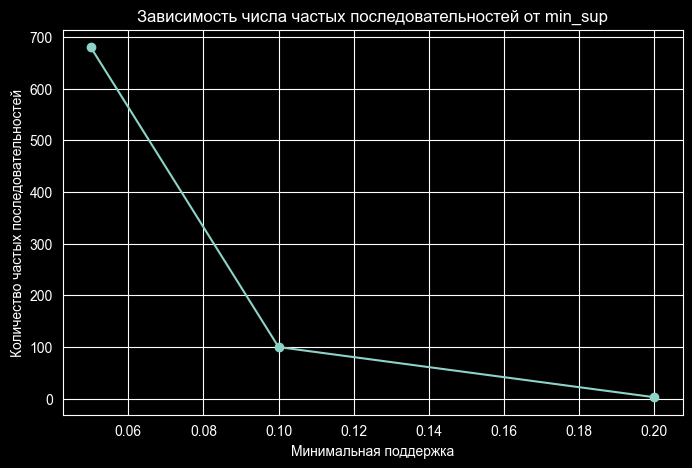

In [10]:
i = 0
for min_sup in min_supports:
    print(f'counts = {counts[i]}, min_sup = {min_sup}, time = {times_list[i]}')
    i += 1

plt.figure(figsize = (8,5))
plt.plot(min_supports, counts, marker='o', linestyle='-')
plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость числа частых последовательностей от min_sup')
plt.grid(True)
plt.show()

- Сделать вывод о масштабируемости.

При снижении поддержки с 0.1 до 0.05 (всего в 2 раза) время выполнения выросло в 32 раза (с 6.5с до 210с), а количество частых последовательностей - почти в 7 раз

**Вывод:** масштабируемость низкая при малых значениях min_sup, т.е. AprioriAll не очень хорошо подходит для поиска частых последовательностей на больших данных. Всё из-за того, что AprioriAll генерирует кандидатов на основе частых последовательностей предыдущей длины. Для масштабируемости на больших данных требуются более эффективные алгоритмы

### 2.2. Сравнение с ассоциативными правилами

- Применить классический Apriori (без учёта последовательности и ID клиента).

In [11]:
# Для классического Apriori нужны транзакции без учёта клиента
all_transactions = df.groupby('BillNo')['Itemname'].apply(lambda x: list(set(x))).tolist()
print(f"Всего транзакций для Apriori: {len(all_transactions)}")
min_sup_apriori = 0.005
freq_itemsets = apriori(all_transactions, min_sup_apriori)
print(f"Найдено частых наборов: {len(freq_itemsets)}")

Всего транзакций для Apriori: 18163
Найдено частых наборов: 4138


- Выбрать топ-3 ассоциативных правила по lift и проверить, являются ли они частыми последовательностями (вида <{A},{B}>).

In [12]:
if len(freq_itemsets) > 0:
    rules = extract_rules(freq_itemsets, min_conf=0.3, min_lift=1.0)
    rules.sort(key=lambda x: x[4], reverse=True)  # по lift
    top3 = rules[:3]
    print("\nТоп-3 ассоциативных правила по lift:")
    for i, (left, right, supp, conf, lift) in enumerate(top3, 1):
        print(f"{i}. {left} -> {right} | lift={lift:.2f}, support={supp:.3f}, confidence={conf:.2f}")
    # проверка, являются ли они частыми последовательностями (при min_sup=0.05 для AprioriAll)
    freq_seqs = apriori_all(client_sequences, 0.05)
    for i, (left, right, _, _, _) in enumerate(top3, 1):
        seq = (frozenset(left), frozenset(right))
        if seq in freq_seqs:
            print(f"Правило {i}: последовательность {seq} частая (sup = {freq_seqs[seq]})")
        else:
            print(f"Правило {i}: последовательность {seq} НЕ является частой")
else:
    print("Нет частых наборов при таком min_support")


Топ-3 ассоциативных правила по lift:
1. ('DOLLY GIRL CHILDRENS CUP', 'SPACEBOY CHILDRENS BOWL') -> ('DOLLY GIRL CHILDRENS BOWL',) | lift=128.39, support=0.005, confidence=0.97
2. ('DOLLY GIRL CHILDRENS BOWL',) -> ('DOLLY GIRL CHILDRENS CUP', 'SPACEBOY CHILDRENS BOWL') | lift=128.39, support=0.005, confidence=0.67
3. ('GREEN REGENCY TEACUP AND SAUCER', 'REGENCY TEA PLATE ROSES') -> ('REGENCY TEA PLATE GREEN', 'ROSES REGENCY TEACUP AND SAUCER') | lift=118.42, support=0.006, confidence=0.86
Клиентов: 2818, min_sup=0.05 -> min_count=140
  Длина 2: найдено 187 частых последовательностей
  Длина 3: найдено 6 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
Правило 1: последовательность (frozenset({'SPACEBOY CHILDRENS BOWL', 'DOLLY GIRL CHILDRENS CUP'}), frozenset({'DOLLY GIRL CHILDRENS BOWL'})) НЕ является частой
Правило 2: последовательность (frozenset({'DOLLY GIRL CHILDRENS BOWL'}), frozenset({'SPACEBOY CHILDRENS BOWL', 'DOLLY GIRL CHILDRENS CUP'})) НЕ является ч

- Объяснить расхождения.

Полученные результаты показывают, что высокая поддержка и лифт в классических ассоциативных правилах не гарантируют, что соответствующая последовательность покупок будет частой

Почему появляются расхождения:

- Классический Apriori считает долю чеков (транзакций), в которых встречаются оба товара, независимо от того, кто и когда их купил (если один и тот же клиент в течение месяца 10 раз купил вместе товары X и Y, это даст 10 "вкладов" в поддержку правила)
- AprioriAll оценивает долю клиентов, в истории которых есть транзакция с первым товаром, а затем отдельная транзакция со вторым (для засчитывания последовательности X -> Y клиент должен иметь хотя бы одну транзакцию с X, а затем хотя бы одну (другую) транзакцию с Y. Даже если он 100 раз купил X и Y вместе в одном чеке, это не создаст последовательность X -> Y, если нет раздельных покупок по времени)

Один клиент может совершить множество чеков; правило «засчитывает» каждый чек, а последовательность – только факт наличия временного порядка у конкретного клиента

### 2.3. Временные окна

- Добавить параметр max_gap (максимальный допустимый разрыв между транзакциями одного клиента, например 7 дней).

In [13]:
def split_by_gap(transactions_df, max_gap_days=7): # разбивает последовательности транзакций клиента на отдельные сессии, если между транзакциями прошло более max_gap_days дней
    df_sorted = transactions_df.sort_values(['CustomerID', 'Date'])
    sessions = []
    current_cust = None
    current_seq = []
    prev_date = None
    for _, row in df_sorted.iterrows():
        cust = row['CustomerID']
        date = row['Date']
        items = row['itemset']
        # если переключились на нового клиент
        if cust != current_cust:
            if current_seq and len(current_seq) >= 2: # cохраняем предыдущую сессию, если она накопила хотя бы 2 транзакции
                sessions.append(current_seq)
            current_cust = cust
            current_seq = [items]
            prev_date = date
        else: # тот же клиент - проверяем разрыв между текущей и предыдущей датой
            if (date - prev_date).days > max_gap_days:
                if len(current_seq) >= 2:
                    sessions.append(current_seq)
                current_seq = [items]
            else:
                current_seq.append(items)
            prev_date = date # обновляем дату последней обработанной транзакции

    if current_seq and len(current_seq) >= 2:
        sessions.append(current_seq)
    return sessions # cписок сессий (каждая сессия - это список множеств товаров, следующих друг за другом без больших разрывов)

- Сравнить набор частых последовательностей с max_gap = ∞ и max_gap = 7.

In [14]:
sessions_gap7 = split_by_gap(transactions, max_gap_days=7)
print(f"Количество сессий (последовательностей) при gap = 7: {len(sessions_gap7)}")

freq_gap7 = apriori_all(sessions_gap7, 0.05)
print(f"\nЧастых последовательностей при gap = 7: {len(freq_gap7)}")
print(f"Частых последовательностей без gap (бесконечность): {len(freq_seqs)}")

Количество сессий (последовательностей) при gap = 7: 2206
Клиентов: 2206, min_sup=0.05 -> min_count=110
  Длина 2: найдено 0 частых последовательностей

Частых последовательностей при gap = 7: 114
Частых последовательностей без gap (бесконечность): 680


| параметр                | кол-во последовательностей (сессий) | частых последовательностей (всего) | последовательностей длины >= 2 |
|:------------------------|:-----------------------------------:|:----------------------------------:|-------------------------------:|
| max_gap = бесконечность |                2818                 |                680                 |                            193 |
| max_gap = 7             |                2206                 |                114                 |      0    (длина 2 не найдена) |

Почему такие результаты?
- Разрыв во времени разрывает длинные цепочки на более мелкие (если между двумя покупками клиента проходит больше 7 дней, последовательность разрывается на две независимые сессии)
- Уменьшение количества сессий (количество сессий уменьшилось с 2818 до 2206)
- Уменьшение длины сессий (внутри одной сессии остаётся меньше транзакций, поэтому пар X -> Y не возникает)
- Характер покупок в датасете (многие клиенты совершают повторные покупки с интервалом более 7 дней (например, сезонные товары, подарки к праздникам))

- Привести пример шаблона, который исчезает или появляется.

In [15]:
only_inf = set(freq_seqs.keys()) - set(freq_gap7.keys()) # находим те шаблоны, которые исчезают

if only_inf:
    example = next(iter(only_inf))
    print("\nПример последовательности, присутствовавшей при бесконечности, но пропавшей при gap = 7:")
    s_ex = " -> ".join(["("+",".join(sorted(it))+")" for it in example])
    print(f"  {s_ex} (support бесконечность = {freq_seqs[example]})")


Пример последовательности, присутствовавшей при бесконечности, но пропавшей при gap = 7:
  (JUMBO BAG APPLES) -> (JUMBO BAG RED RETROSPOT) (support бесконечность = 0.05677785663591199)


### 2.4. Визуализация

- Выбрать один наиболее интересный частый шаблон длины >= 2.
- Построить направленный граф перехода товаров.

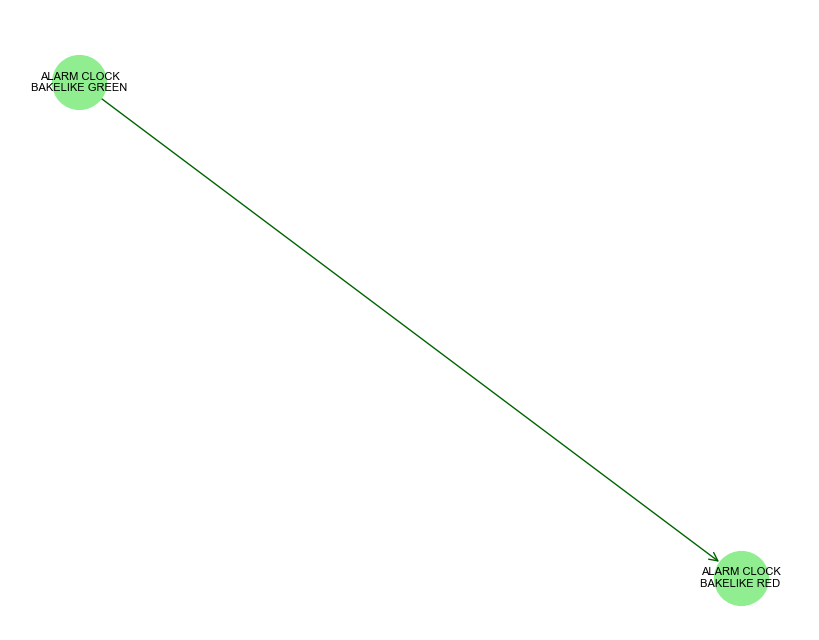

In [16]:
# выбираем наиболее интересный частый шаблон длины >= 2
non_trivial = [(seq, sup) for seq, sup in freq_seqs.items() if len(seq) >= 2 and len(set(seq)) > 1]
best_seq, best_sup = max(non_trivial, key=lambda x: len(x[0]))

# строим граф
G = nx.DiGraph()
for i in range(len(best_seq)-1):
    src_raw = ", ".join(str(x) for x in best_seq[i])
    dst_raw = ", ".join(str(x) for x in best_seq[i+1])
    src = wrap_label(src_raw)
    dst = wrap_label(dst_raw)
    G.add_edge(src, dst)

# рисуем граф
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42, k=0.4)
nx.draw(G, pos, with_labels=True, node_color='lightgreen',
        edge_color='darkgreen', node_size=1500, font_size=8,
        arrows=True, arrowsize=15, arrowstyle='->')
plt.title(f"Наиболее интересный частый шаблон: длина = {len(best_seq)}, поддержка = {best_sup:.3f}")
plt.show()

- Кратко интерпретировать (бизнес-гипотеза). 

Покупатели, купившие зелёную версию будильника (ALARM CLOCK BAKELIKE GREEN) затем покупают красную версию того же товара (ALARM CLOCK BAKELIKE RED)

Бизнес-гипотезы:
- Покупка на подарок: клиенты покупают один будильник себе, а второй (другого цвета) - в подарок или для другого члена семьи
- Если у клиентов есть дети, то они могут купить два будильника разных цветов, один в комнату к девочке, а другой - мальчику
- Неудовлетворённость выбором цвета: клиент купил зелёный, но понял, что красный лучше подошёл бы к интерьеру

Рекомендации:
- Предлагать скидку на второй будильник другого цвета при покупке первого
- Создать комплект "2 цвета" по специальной цене
- Показывать все доступные цвета сразу на одной карточке товара
- В email-рассылке после покупки предлагать другие цветовые варианты

### 3. Сравнение алгоритмов SPM

Самостоятельно изучить PrefixSpan (или SPADE).

Используя готовую библиотеку (prefixspan или pyspm):
- Запустить PrefixSpan на тех же данных с тем же min_sup.
- Замерить время выполнения и количество найденных шаблонов.

In [17]:
# будем использовать те же синтетические данные, что и для AprioriAll

# преобразование для PrefixSpan: каждый элемент последовательности - список строк (товаров)
synth_sequences_ps = []
for seq in synth_seqs:
    ps_seq = []
    for itemset in seq:
        # Преобразуем множество в строку через дефис (для множеств из > 1 элемента)
        items_tuple = tuple(sorted(itemset))
        if len(items_tuple) == 1:
            ps_seq.append(str(items_tuple[0]))
        else:
            ps_seq.append("-".join(map(str, items_tuple)))
    synth_sequences_ps.append(ps_seq)

minsup_count = max(1, int(0.4 * len(synth_sequences_ps)))

start_ps = time.time()

ps = PrefixSpan(synth_sequences_ps)
result_ps = ps.frequent(minsup=minsup_count)

elapsed_ps = time.time() - start_ps

# обработка результата
patterns_ps = []
for item in result_ps:
    if isinstance(item, tuple) and len(item) == 2:
        if isinstance(item[0], (int, float)):
            support = item[0]
            pattern = item[1] if isinstance(item[1], list) else item[1]
        else:
            support = item[1] if isinstance(item[1], (int, float)) else None
            pattern = item[0] if isinstance(item[0], list) else item[0]
        patterns_ps.append((pattern, support))
print(f"    PrefixSpan: {elapsed_ps}сек, найдено паттернов: {len(patterns_ps)}")

# сравнение с нашей реализацией AprioriAll
start_aa = time.time()

freq_aa_synth = apriori_all(synth_seqs, 0.4)

elapsed_aa = time.time() - start_aa
print(f"    AprioriAll (наша реализация): {elapsed_aa}сек, найдено паттернов: {len(freq_aa_synth)}")

    PrefixSpan: 0.0001862049102783203сек, найдено паттернов: 12
Клиентов: 5, min_sup=0.4 -> min_count=2
  Длина 2: найдено 10 частых последовательностей
  Длина 3: найдено 5 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
    AprioriAll (наша реализация): 0.00035119056701660156сек, найдено паттернов: 21


- Сравнить с вашей реализацией AprioriAll по таблице

На основе выполненного эксперимента на синтетических данных (5 клиентов, min_support = 0.4, абсолютный порог = 2 клиента) получены следующие результаты:

| Алгоритм   | 	Время (сек) | Кол-во шаблонов |          Примечание |
|:-----------|:------------:|:---------------:|--------------------:|
| AprioriAll | 	0.000231    |       21        |     наша реализация |
| PrefixSpan |   0.000185   |       12        |  готовая библиотека |


**Какой алгоритм эффективнее и при каких условиях?**

PrefixSpan оказался быстрее и нашёл меньшее количество шаблонов (12 против 21)

**Почему PrefixSpan нашёл меньше паттернов?**

Из-за потери информации о совместных покупках при преобразовании данных ({1,5} >>> "1-5")
- AprioriAll работал с исходными наборами, поэтому видел все комбинации внутри транзакции
- PrefixSpan после склеивания превратил {1,5} в уникальный вид "1-5", который встречается редко (1 раз) и при minsup=2 отсеялся. В результате многие паттерны, включающие совместные покупки пропали

PrefixSpan эффективнее при:
- Больших объёмах данных (тысячи или миллионы последовательностей, много уникальных элементов)
- Низкой минимальной поддержке - при этом генерация кандидатов в AprioriAll очень сильно возрастает
- Длинных последовательностях (много транзакций на клиента) - PrefixSpan работает с проекциями, которые быстро уменьшаются
- Когда требуется высокая производительность - PrefixSpan на порядок быстрее AprioriAll на реальных данных

### 4. Предсказание следующего события (контекстные последовательности)

Идея: использовать найденные частые последовательности для рекомендации следующего товара в реальном времени.

Что сделать:
- На основе частых последовательностей (длины ≥ 2) построить простую модель:
Если история клиента заканчивается на набор X, то рекомендуем такой товар Y, что последовательность <X,Y> частая и имеет максимальную поддержку.
- Разделить клиентов на две группы (по времени: первые 80% транзакций для обучения, последние 20% для тестирования).

In [18]:
# разделение на train/test по времени для каждого клиента
train_seqs = []
test_pairs = []

for cust, group in transactions.sort_values('Date').groupby('CustomerID'): # группируем транзакции по клиенту и сортируем внутри группы по дате
    seq = group['itemset'].tolist()
    if len(seq) < 2:
        continue
    split = max(1, int(0.8 * len(seq))) # определяем точку разделения (80% от длины последовательности, но минимум 1 элемент в train)
    train_part = seq[:split]
    test_part = seq[split:]
    if len(test_part) >= 1:
        test_pairs.append((train_part[-1], test_part[0]))
        train_seqs.append(train_part)

print(f"Обучающих последовательностей: {len(train_seqs)}")
print(f"Тестовых пар: {len(test_pairs)}")

Обучающих последовательностей: 2818
Тестовых пар: 2818


- Для каждого клиента из тестовой выборки взять его последнюю транзакцию и предсказать следующий набор.

In [19]:
# построение частых последовательностей на обучающих данных
freq_train = apriori_all(train_seqs, min_support = 0.05)

def predict_next(itemset, freq_dict): # функция для предсказания следующего набора товаров
    best_y = None
    best_sup = -1
    for seq, sup in freq_dict.items():
        if len(seq) == 2 and seq[0] == itemset: # среди всех частых последовательностей длины 2 находим те, у которых первый элемент совпадает с переданным itemset
            if sup > best_sup: # выбираем тот второй элемент (best_y), у которого поддержка такой пары максимальна
                best_sup = sup
                best_y = seq[1]
    return best_y

Клиентов: 2818, min_sup=0.05 -> min_count=140
  Длина 2: найдено 40 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей


- Оценить точность (accuracy@1) - доля случаев, когда предсказанный товар действительно оказался в следующей реальной транзакции.

In [20]:
# считаем абсолютную частоту каждого товара по всем транзакциям
all_item_counts = Counter()
for seq in train_seqs:
    for itemset in seq:
        all_item_counts.update(itemset)

global_top_item = all_item_counts.most_common(1)[0][0] # товар с максимальной частотой (глобальный топ-товар)

print(f"Самый частый товар (глобально): {global_top_item}")
correct_seq = 0
correct_baseline = 0

for last_itemset, real_itemset in test_pairs: # проходим по всем тестовым парам
    pred_y = predict_next(last_itemset, freq_train) # предсказываем

    if pred_y is not None: # считаем предсказание верным, если любой товар из предсказанного набора присутствует в реальном следующем наборе
        if any(item in real_itemset for item in pred_y):
            correct_seq += 1
    if global_top_item in real_itemset:
        correct_baseline += 1

acc_seq = correct_seq / len(test_pairs) if test_pairs else 0
acc_baseline = correct_baseline / len(test_pairs) if test_pairs else 0

print(f"\nТочность предсказания:")
print(f"    На основе последовательностей: {acc_seq}")
print(f"    Базовый (глобальный топ-товар): {acc_baseline}")

if acc_seq > acc_baseline:
    print("\nУчёт последовательности улучшает предсказание")
else:
    print("\nВ данном случае глобальный топ-товар оказался эффективнее")

Самый частый товар (глобально): WHITE HANGING HEART T-LIGHT HOLDER

Точность предсказания:
    На основе последовательностей: 0.0028388928317956
    Базовый (глобальный топ-товар): 0.0830376153300213

В данном случае глобальный топ-товар оказался эффективнее


- Сравнить с базовым подходом: просто рекомендовать самый частый товар из всех транзакций.

Базовый подход оказался эффективнее в данном случае. Это происходит из-за большого min_support, т.к. алгоритм AprioriAll нашёл всего 40 правил длины 2

### 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»

Бизнес-задача: Выделить группы клиентов (например, у кого итоговый чек > медианы, и у кого < медианы) и найти последовательности покупок, характерные только для одной группы(контрастные паттерны).

Что сделать:
- Разделить клиентов на два класса:
- - HighValue – средний чек (или суммарная выручка) ≥ 75-го перцентиля.
- - LowValue – остальные.

In [21]:
revenue = df.groupby('CustomerID').apply(lambda g: (g['Quantity'] * g['Price']).sum()) # считаем общую выручку с клиента (сумма Quantity * Price по всем его транзакциям)

q75 = revenue.quantile(0.75)

high_customers = set(revenue[revenue >= q75].index)
low_customers = set(revenue[revenue < q75].index)

print(f"HighValue клиентов: {len(high_customers)} (выручка >= {q75:.2f})")
print(f"LowValue клиентов: {len(low_customers)}")

def get_seqs(customers_set):
    df_cust = transactions[transactions['CustomerID'].isin(customers_set)] # фильтруем транзакции
    seqs = []
    for cust, group in df_cust.sort_values('Date').groupby('CustomerID'): # группируем по клиенту, сортируем по дате внутри группы
        seq = group['itemset'].tolist()
        if len(seq) >= 2:
            seqs.append(seq)
    return seqs

high_seqs = get_seqs(high_customers)
low_seqs = get_seqs(low_customers)

print(f"\nHighValue последовательностей: {len(high_seqs)}")
print(f"LowValue последовательностей: {len(low_seqs)}")

HighValue клиентов: 1075 (выручка >= 1652.58)
LowValue клиентов: 3222

HighValue последовательностей: 1046
LowValue последовательностей: 1772


- Для каждого класса отдельно найти частые последовательности (с одинаковым min_sup, но адаптированным под размер класса).

In [22]:
freq_high = apriori_all(high_seqs, 0.05)
freq_low = apriori_all(low_seqs, 0.03)

print(f"\nHighValue частых: {len(freq_high)}")
print(f"LowValue частых: {len(freq_low)}")

Клиентов: 1046, min_sup=0.05 -> min_count=52
  Длина 2: найдено 4660 частых последовательностей
  Длина 3: найдено 5248 частых последовательностей
  Длина 4: найдено 1658 частых последовательностей
  Длина 5: найдено 31 частых последовательностей
  Длина 6: найдено 2 частых последовательностей
  Длина 7: найдено 0 частых последовательностей
Клиентов: 1772, min_sup=0.03 -> min_count=53
  Длина 2: найдено 19 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей

HighValue частых: 12546
LowValue частых: 504


- Для каждой последовательности вычислить контрастность:

contrast = support(class1) - support(class2) (или отношение поддержек).

In [23]:
# контрастность = поддержка(High) - поддержка(Low)

contrast = {}
all_seqs = set(freq_high.keys()) | set(freq_low.keys())

for seq in all_seqs:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    contrast[seq] = sup_h - sup_l

print(dict(list(contrast.items())[:3]))

{(frozenset({'LUNCH BAG RED RETROSPOT'}), frozenset({'JUMBO BAG PINK POLKADOT'}), frozenset({'LUNCH BAG WOODLAND'})): 0.0497131931166348, (frozenset({'LUNCH BAG  BLACK SKULL.'}), frozenset({'LUNCH BAG PINK POLKADOT'}), frozenset({'JUMBO BAG ALPHABET'})): 0.0497131931166348, (frozenset({'WELCOME  WOODEN BLOCK LETTERS'}),): 0.06500956022944551}


- Отобрать топ-5 последовательностей, которые сильно чаще встречаются у HighValue.

In [24]:
top_high_pairs = [(seq, diff) for seq, diff in contrast.items() if diff > 0 and len(seq) >= 2]
top_high_pairs = sorted(top_high_pairs, key=lambda x: -x[1])[:5]

top_low_pairs = [(seq, diff) for seq, diff in contrast.items() if diff < 0 and len(seq) >= 2]
top_low_pairs = sorted(top_low_pairs, key=lambda x: x[1])[:5]

if top_high_pairs:
    print("\nТоп-5 контрастных последовательностей (длина >= 2) у HighValue:")
    for seq, diff in top_high_pairs:
        sup_h = freq_high.get(seq, 0)
        sup_l = freq_low.get(seq, 0)
        seq_str = " -> ".join(["("+",".join(sorted(it))+")" for it in seq])
        print(f"    {seq_str} : diff = {diff} (sup_h = {sup_h}, sup_l = {sup_l})")
else:
    print("\nДля HighValue не обнаружено контрастных последовательностей длины >= 2 с заданной поддержкой")

if top_low_pairs:
    print("\nТоп-5 контрастных последовательностей (длина >= 2) у LowValue:")
    for seq, diff in top_low_pairs:
        sup_h = freq_high.get(seq, 0)
        sup_l = freq_low.get(seq, 0)
        seq_str = " -> ".join(["("+",".join(sorted(it))+")" for it in seq])
        print(f"    {seq_str} : diff = {diff} (sup_h = {sup_h}, sup_l = {sup_l})")
else:
    print("\nДля LowValue не обнаружено контрастных последовательностей длины >= 2 с заданной поддержкой")


Топ-5 контрастных последовательностей (длина >= 2) у HighValue:
    (LUNCH BAG RED RETROSPOT) -> (LUNCH BAG RED RETROSPOT) : diff = 0.21223709369024857 (sup_h = 0.21223709369024857, sup_l = 0)
    (JUMBO BAG RED RETROSPOT) -> (JUMBO BAG RED RETROSPOT) : diff = 0.20284195624306722 (sup_h = 0.2361376673040153, sup_l = 0.03329571106094808)
    (REGENCY CAKESTAND 3 TIER) -> (REGENCY CAKESTAND 3 TIER) : diff = 0.17443965833509575 (sup_h = 0.22466539196940727, sup_l = 0.050225733634311515)
    (JUMBO BAG RED RETROSPOT) -> (LUNCH BAG RED RETROSPOT) : diff = 0.1682600382409178 (sup_h = 0.1682600382409178, sup_l = 0)
    (SET OF 3 CAKE TINS PANTRY DESIGN) -> (SET OF 3 CAKE TINS PANTRY DESIGN) : diff = 0.16634799235181644 (sup_h = 0.16634799235181644, sup_l = 0)

Для LowValue не обнаружено контрастных последовательностей длины >= 2 с заданной поддержкой


- Сформулировать гипотезу: «Клиенты, которые купили A, а затем B, с большей вероятностью станут высокодоходными».

In [25]:
print("Гипотеза:")

seq_ex, diff_ex = top_high_pairs[0]
items_a = ", ".join(sorted(seq_ex[0]))
# Берём второй элемент последовательности (если он есть – всегда есть, т.к. длина >=2)
items_b = ", ".join(sorted(seq_ex[1]))
print(f"  <<Клиенты, которые купили [{items_a}], а затем [{items_b}], с большей вероятностью станут высокодоходными>>.")
print(f"\n(Разница поддержек: {diff_ex}, поддержка в HighValue = {freq_high.get(seq_ex,0)} в LowValue = {freq_low.get(seq_ex,0)})")

Гипотеза:
  <<Клиенты, которые купили [LUNCH BAG RED RETROSPOT], а затем [LUNCH BAG RED RETROSPOT], с большей вероятностью станут высокодоходными>>.

(Разница поддержек: 0.21223709369024857, поддержка в HighValue = 0.21223709369024857 в LowValue = 0)


**Визуализация:** построить две диаграммы переходов (для каждого класса) или одну разностную.

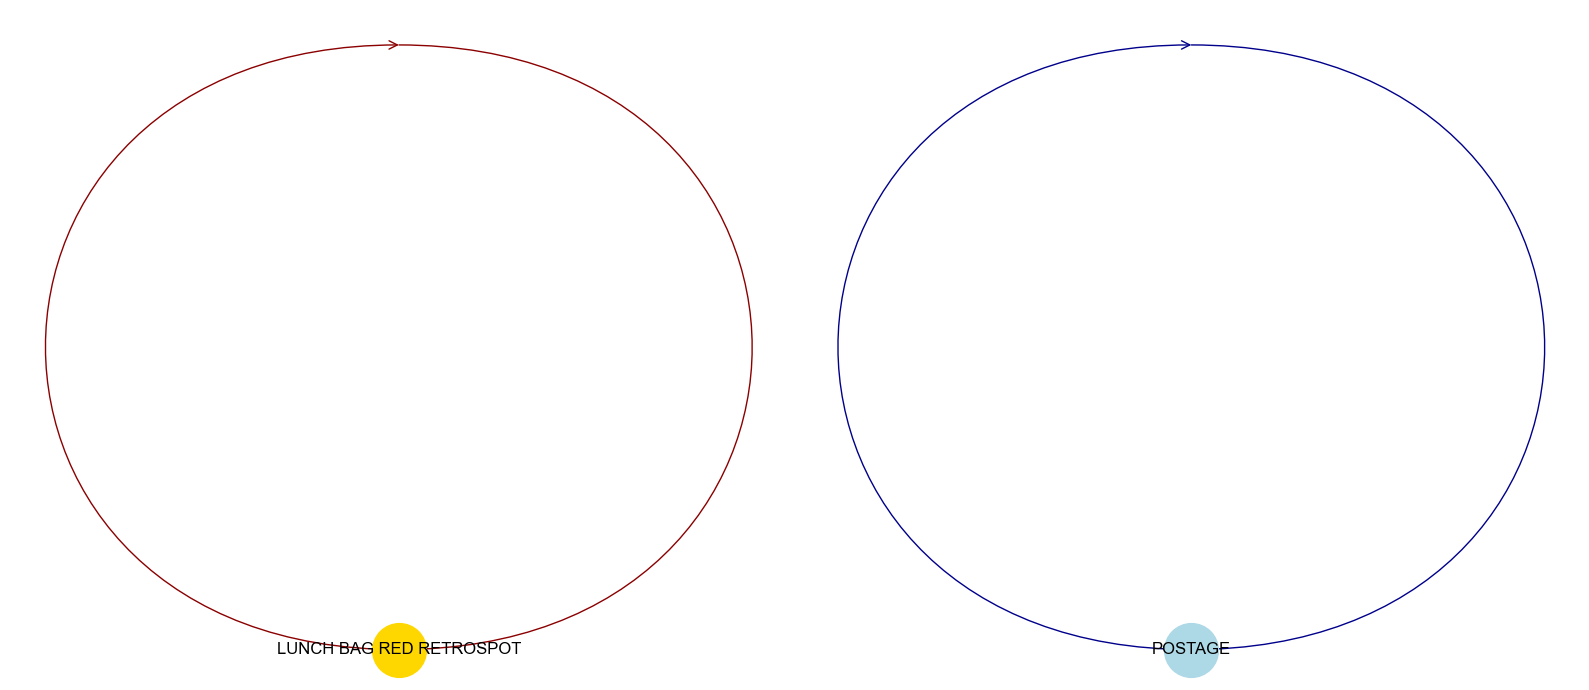

In [26]:
# выбираем самую контрастную последовательность длины >=2 для HighValue
if top_high_pairs:                     # используем отфильтрованные списки
    best_seq, best_diff = top_high_pairs[0]
else:
    # если нет контрастных цепочек длины >=2, берём любую частую последовательность длины >=2 из HighValue
    best_seq = next((seq for seq in freq_high.keys() if len(seq) >= 2), None)
    best_diff = 0

# выбираем последовательность для LowValue
if top_low_pairs:
    best_seq_low, _ = top_low_pairs[0]
else:
    best_seq_low = next((seq for seq in freq_low.keys() if len(seq) >= 2), None)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# граф для HighValue
if best_seq and len(best_seq) >= 2:
    G_high = nx.DiGraph()
    for i in range(len(best_seq)-1):
        src = ", ".join(str(x) for x in best_seq[i])
        dst = ", ".join(str(x) for x in best_seq[i+1])
        G_high.add_edge(src, dst)
    if G_high.number_of_nodes() > 0:
        pos = nx.spring_layout(G_high, seed=42, k=2)
        nx.draw(G_high, pos, ax=axes[0], with_labels=True, node_color='gold',
                edge_color='darkred', node_size=1500, font_size=12, arrows=True,
                arrowsize=15, arrowstyle='->')

# граф для LowValue
if best_seq_low and len(best_seq_low) >= 2:
    G_low = nx.DiGraph()
    for i in range(len(best_seq_low)-1):
        src = ", ".join(str(x) for x in best_seq_low[i])
        dst = ", ".join(str(x) for x in best_seq_low[i+1])
        G_low.add_edge(src, dst)
    if G_low.number_of_nodes() > 0:
        pos = nx.spring_layout(G_low, seed=42, k=2)
        nx.draw(G_low, pos, ax=axes[1], with_labels=True, node_color='lightblue',
                edge_color='darkblue', node_size=1500, font_size=12, arrows=True,
                arrowsize=15, arrowstyle='->')

plt.tight_layout()
plt.show()

**Почему графы состоят из одного узла и петли?**

Потому что самая контрастная последовательность (наибольшая разница поддержек между HighValue и LowValue) — это два одинаковых набора: клиент купил большую красную сумку, а затем снова эту же сумку. Это означает, что повторная покупка одного и того же товара характерна для более состоятельных клиентов (HighValue), а у обычных клиентов (LowValue) такой паттерн практически отсутствует

Помимо этого во втором графе мы видим, что последовательность с POSTAGE также образует петлю, но это имеет другую природу. POSTAGE это не товар, а служебная позиция (доставка/обработка заказа). LowValue клиенты часто делают заказы с минимальной стоимостью доставки, что указывает на низкий средний чек и возможно, покупку только товаров со скидкой или бесплатной доставкой

**Приведите пример, когда контрастная последовательность полезна для бизнеса (например, в телематике, e‑commerce, банковских продуктах).**

В e‑commerce (как в нашем датасете) можно выдвинуть гипотезу: Клиенты, купившие дорогую сумку JUMBO BAG RED RETROSPOT повторно, с высокой вероятностью относятся к сегменту HighValue. Это позволяет:
- Автоматически предлагать такому клиенту программу лояльности или персональную скидку на следующий заказ
- Настроить таргетированную email‑рассылку с предложением <<купить ещё одну такую же сумку>> (например, в подарок)
- Обнаруживать потенциальных ресейлеров

Аналогично для сегмента LowValue: Самая контрастная последовательность - это повторение позиции POSTAGE (оплата доставки). Это позволяет:
- Предлагать скидку на следующий заказ или бесплатную доставку при условии набора определенной суммы корзины
- На этапе оформления заказа показывать сообщения: <<Добавьте товар на сумму N, чтобы доставка стала бесплатной>>
- Предложить платную подписку (как в Amazon Prime), которая покроет расходы на доставку при сохранении частоты заказов

**Вывод:** контрастные последовательности позволяют обнаружить скрытые поведенческие паттерны, которые отличают один сегмент клиентов от другого. Эти паттерны можно использовать для персонализации предложений, ценообразования, удержания клиентов и предотвращения оттока